# 0 · Acquire scenes

Two changes from the previous version:

**1. Per-area date selection.** The original AOI keeps its hand-checked dates
(`ls_dates.txt` / `s2_dates.txt`). The new east AOI has no vetted dates, so the
least-cloudy scene per year is chosen automatically — scored on the **actual
QA/SCL pixels inside the bbox**, because scene-level `eo:cloud_cover` describes
a whole tile and is often wrong for a small AOI.

**2. Configurable resolution.** `TARGET_RES = 10` keeps Sentinel-2 at native
resolution so predictions aren't blocky. Landsat years are upsampled (no detail
gained, none lost). Use 30 only if you need the small storage footprint.

In [9]:
from datetime import datetime, timedelta, timezone
from pathlib import Path

import numpy as np
import xarray as xr
import rioxarray  # noqa: registers .rio
import matplotlib.pyplot as plt
import pystac_client
import odc.stac

try:
    import planetary_computer as pc
except ImportError:
    pc = None
    print("planetary-computer not installed -> Landsat years unavailable")

### Configuration — pick the area here

In [10]:
# Everything lives here - NOT on C:
PROJECT_ROOT = Path(r"D:\Users\b1120440\projects\morpheo\glacial_lake_pred")
PROJECT_ROOT.mkdir(parents=True, exist_ok=True)

AREA = "east"          # "original" or "east"

AREAS = {
    "vatna": {
        "bbox": {"west": -16.5, "south": 63.97, "east": -16.1, "north": 64.2},
        "dates": "manual",
        "date_files": [PROJECT_ROOT / "ls_dates.txt", PROJECT_ROOT / "s2_dates.txt"],
        "outdir": PROJECT_ROOT / "scenes" / "vatna",
        "prefix": "vatna",
    },
    "east": {
        "bbox": {"west": -15.92166, "south": 64.26290,
                 "east": -15.25765, "north": 64.50511},
        "dates": "auto",
        "years": range(1985, 2027),
        "outdir": PROJECT_ROOT / "scenes" / "east",
        "prefix": "east",
    },
}

CFG = AREAS[AREA]
BBOX = CFG["bbox"]
BBOX_LIST = [BBOX["west"], BBOX["south"], BBOX["east"], BBOX["north"]]
OUTDIR = Path(CFG["outdir"]); OUTDIR.mkdir(parents=True, exist_ok=True)

TARGET_CRS = "EPSG:32627"

# 10 m keeps Sentinel-2 native -> smooth, detailed lake edges.
# 30 m is the old setting (Landsat-limited) and is what makes predictions boxy.
TARGET_RES = 10

# Landsat revisits every 16 days (and only one satellite for much of the
# record), so a 2-month window often yields nothing usable in Iceland.
# Sentinel-2 revisits every ~5 days, so a tight window is fine.
WINDOW = ("06-01", "09-30") # was 07-01, 08-31 for east and vatna
MAX_CLOUD = 60
MIN_COVER = 0.98      # scene must cover >= this fraction of the AOI
MAX_CLOUD_AOI = 0.35  # and have <= this fraction cloud over the AOI

# Landsat 7 lost its scan-line corrector in 2003: every later scene has
# diagonal nodata stripes. Allow them only if nothing else exists.
ALLOW_SLC_OFF = False
SCORE_RES = 60                  # coarse res used only for cloud scoring (fast)

print(f"AREA={AREA}  res={TARGET_RES} m  bbox={BBOX_LIST}  -> {OUTDIR}/")

AREA=east  res=10 m  bbox=[-15.92166, 64.2629, -15.25765, 64.50511]  -> D:\Users\b1120440\projects\morpheo\glacial_lake_pred\scenes\east/


### Date selection

In [11]:
def read_dates(path) -> dict:
    """'1985: 05-08-1985' -> {1985: '1985-08-05'}"""
    out, p = {}, Path(path)
    if not p.exists():
        print(f"  ! {path} missing"); return out
    for line in p.read_text().splitlines():
        line = line.strip()
        if not line or ":" not in line:
            continue
        yr, d = line.split(":", 1)
        out[int(yr)] = datetime.strptime(d.strip(), "%d-%m-%Y").strftime("%Y-%m-%d")
    return out


_es = pystac_client.Client.open("https://earth-search.aws.element84.com/v1")
_pc = (pystac_client.Client.open("https://planetarycomputer.microsoft.com/api/stac/v1",
                                 modifier=pc.sign_inplace) if pc else None)

if _pc is None:
    print("!! planetary-computer is NOT installed - every Landsat year (pre-2016)\n"
          "   will silently return 'no usable scene'.  pip install planetary-computer")


def catalog_for(year):
    """S2 from Earth Search (2016+), Landsat from Planetary Computer."""
    return (_es, "sentinel-2-l2a") if year >= 2017 else (_pc, "landsat-c2-l2")


def platforms_for(year):
    """Which Landsat platforms are acceptable for a given year."""
    if year <= 1998:
        return ["landsat-4", "landsat-5"]
    if year <= 2012:
        return ["landsat-7"] + (["landsat-5"] if year <= 2011 else [])
    return ["landsat-8", "landsat-9"]


def aoi_quality(item, collection):
    """-> (cover, cloud, bright) for this item over the AOI.
 
    cover  : fraction of AOI pixels that contain data (1.0 = full coverage)
    cloud  : fraction of the COVERED pixels flagged cloud/shadow (snow not flagged)
    bright : median visible reflectance of covered pixels - high means snow
    """
    qa_band = "scl" if collection == "sentinel-2-l2a" else "qa_pixel"
    vis_band = "green"
    try:
        ds = odc.stac.load([item], bands=[qa_band, vis_band], bbox=BBOX_LIST,
                           crs=TARGET_CRS, resolution=SCORE_RES,
                           resampling="nearest", chunks={}).isel(time=0)
        qa = ds[qa_band].compute().values
        vis = ds[vis_band].compute().values.astype("float32")
    except Exception:
        return np.nan, np.nan, np.nan
    if qa.size == 0:
        return np.nan, np.nan, np.nan
 
    if collection == "sentinel-2-l2a":
        nodata = qa == 0
        bad = np.isin(qa, [3, 8, 9, 10])            # shadow, cloud, cloud, cirrus
        refl = vis / 10000.0
    else:
        qa = qa.astype("uint16")
        nodata = (qa & 1) != 0                      # Landsat C2 fill is BIT 0
        bits = (1 << 1) | (1 << 2) | (1 << 3) | (1 << 4)
        bad = (qa & bits) != 0
        refl = vis * 0.0000275 - 0.2
 
    cover = float((~nodata).mean())
    if cover <= 0:
        return 0.0, np.nan, np.nan
    cloud = float(bad[~nodata].mean())
    r = np.clip(refl[~nodata], 0, 1)
    bright = float(np.median(r[r > 0])) if (r > 0).any() else np.nan
    return cover, cloud, bright
 
 
def pick_best_date(year, top_k=12):
    """Least-cloudy FULLY-COVERING scene over the AOI, in that sensor's window.
 
    Candidates are rejected outright if they do not cover the AOI, are too
    cloudy over it, or are snow-covered (high visible reflectance). Only if
    nothing passes is the best partial scene returned, clearly marked.
    """
    cat, coll = catalog_for(year)
    if cat is None:
        return None, None, None, None
    lo, hi = WINDOW
    query = {"eo:cloud_cover": {"lt": MAX_CLOUD}}
    if coll == "landsat-c2-l2":
        plats = platforms_for(year)
        if not ALLOW_SLC_OFF and year >= 2003:
            plats = [p for p in plats if p != "landsat-7"]
        if not plats:
            return None, None, None, None
        query["platform"] = {"in": plats}
 
    items = list(cat.search(collections=[coll], bbox=BBOX_LIST,
                            datetime=f"{year}-{lo}/{year}-{hi}",
                            query=query).items())
    if not items:
        return None, None, None, None
 
    # cheap metadata pre-sort, then check real AOI pixels on the best candidates
    items.sort(key=lambda it: it.properties.get("eo:cloud_cover", 100.0))
    passed, partial = [], []
    for it in items[:top_k]:
        cover, cloud, bright = aoi_quality(it, coll)
        if not np.isfinite(cover):
            continue
        rec = (cloud if np.isfinite(cloud) else 1.0, cover, bright, it)
        if cover < MIN_COVER:
            partial.append(rec); continue
        if not np.isfinite(cloud) or cloud > MAX_CLOUD_AOI:
            continue
        passed.append(rec)
 
    pool, note = (passed, "") if passed else (partial, "PARTIAL")
    if not pool:
        return None, None, None, None
    pool.sort(key=lambda r: r[0])
    cloud, cover, bright, best = pool[0]
    plat = best.properties.get("platform", coll.split("-")[0])
    return best.datetime.strftime("%Y-%m-%d"), (cover, cloud, bright), plat, note
 



if CFG["dates"] == "manual":
    DATES = {}
    for f in CFG["date_files"]:
        DATES.update(read_dates(f))
    print(f"{len(DATES)} manual dates: {min(DATES)}-{max(DATES)}")
else:
    DATES, missing, flagged = {}, [], []
    print(f"{'year':6}{'date':12}{'platform':13}{'cover':>7}{'cloud':>7}{'bright':>8}  flag")
    for y in CFG["years"]:
        d, q, plat, note = pick_best_date(y)
        if d is None:
            print(f"{y:<6}{'-':12}{'-':13}{'':>7}{'':>7}{'':>8}  NO USABLE SCENE")
            missing.append(y); continue
        cover, cloud, bright = q
        DATES[y] = d
        if note:
            flagged.append(y)
        print(f"{y:<6}{d:12}{plat:13}{cover:7.2f}{cloud:7.2f}{bright:8.3f}  {note}")
 
    print(f"\n{len(DATES)} years selected, {len(missing)} missing: {missing}")
    if flagged:
        print(f"{len(flagged)} year(s) only partially covered: {flagged}")
    dst = PROJECT_ROOT / f"{CFG['prefix']}_dates.txt"
    dst.write_text("".join(
        f"{y}: {datetime.strptime(d, '%Y-%m-%d').strftime('%d-%m-%Y')}\n"
        for y, d in sorted(DATES.items())))
    print(f"wrote {dst}")


year  date        platform       cover  cloud  bright  flag
1985  1985-08-30  landsat-5       1.00   0.07   0.277  
1986  1986-09-02  landsat-5       1.00   0.12   0.118  
1987  1987-08-27  landsat-5       1.00   0.02   0.114  
1988  1988-07-05  landsat-5       1.00   0.01   0.126  
1989  1989-07-31  landsat-5       1.00   0.13   0.127  
1990  1990-09-29  landsat-5       1.00   0.13   0.129  
1991  1991-09-07  landsat-5       1.00   0.01   0.109  
1992  1992-07-16  landsat-5       1.00   0.00   0.585  
1993  1993-06-15  landsat-5       0.58   0.00   0.867  PARTIAL
1994  1994-06-11  landsat-5       1.00   0.00   0.489  
1995  1995-06-30  landsat-5       1.00   0.01   0.164  
1996  1996-09-29  landsat-5       1.00   0.10   0.116  
1997  1997-06-28  landsat-5       1.00   0.01   0.138  
1998  1998-07-10  landsat-5       1.00   0.12   0.150  
1999  1999-08-20  landsat-7       1.00   0.24   0.160  
2000  2000-09-16  landsat-7       1.00   0.04   0.101  
2001  2001-09-03  landsat-7       1.0

### Fetch, mosaic and scale

`to_reflectance` is unchanged — it defines the convention the model was trained
on, so it must not drift.

In [12]:
def find_items(date, collection, window_days=0):
    """All scenes on `date` (optionally +/- a few days) over the AOI."""
    cat, _ = catalog_for(int(date[:4]))
    t = datetime.strptime(date, "%Y-%m-%d").replace(tzinfo=timezone.utc)
    lo = (t - timedelta(days=window_days)).strftime("%Y-%m-%d")
    hi = (t + timedelta(days=window_days)).strftime("%Y-%m-%d")
    items = list(cat.search(collections=[collection], bbox=BBOX_LIST,
                            datetime=f"{lo}T00:00:00Z/{hi}T23:59:59Z").items())
    items.sort(key=lambda it: (abs((it.datetime - t).total_seconds()),
                               it.properties.get("eo:cloud_cover", 100.0)))
    return items


def load_rgbn(items, resolution):
    """Mosaic same-day scenes; Landsat calls NIR 'nir08', Sentinel-2 'nir'."""
    assets = set(items[0].assets)
    nir = "nir" if "nir" in assets else "nir08"
    if nir not in assets:
        raise KeyError(f"no NIR asset; available: {sorted(assets)}")
    ds = odc.stac.load(items, bands=["red", "green", "blue", nir],
                       bbox=BBOX_LIST, crs=TARGET_CRS, resolution=resolution,
                       groupby="solar_day", chunks={}).isel(time=0)
    if nir != "nir":
        ds = ds.rename({nir: "nir"})
    return ds.compute()


def to_reflectance(ds, collection):
    """DN -> surface reflectance 0-1. THIS DEFINES THE TRAINING CONVENTION."""
    if collection == "landsat-c2-l2":
        ds = ds.where(ds > 0) * 0.0000275 - 0.2
    else:
        ds = ds.where(ds > 0) / 10000.0
    return ds.clip(0, 1)

In [13]:
written, skipped = [], []
for year, date in sorted(DATES.items()):
    dst = OUTDIR / f"{CFG['prefix']}_{date.replace('-', '')}.tif"
    if dst.exists():
        print(f"{year}: exists, skipping"); written.append(dst); continue

    _, coll = catalog_for(year)
    try:
        items = find_items(date, coll)
        if not items:
            print(f"{year}: no items on {date}"); skipped.append(year); continue
        ds = to_reflectance(load_rgbn(items, TARGET_RES), coll)

        # band order red, green, blue, nir - the cube builder assumes this
        da = ds[["red", "green", "blue", "nir"]].to_array(dim="band")
        da.rio.write_crs(TARGET_CRS).rio.to_raster(dst, compress="DEFLATE")

        med = float(np.nanmedian(da.values[np.isfinite(da.values) & (da.values > 0)]))
        print(f"{year}: {dst.name}  median {med:.3f}")
        written.append(dst)
    except Exception as e:
        print(f"{year}: FAILED - {e}"); skipped.append(year)

print(f"\n{len(written)} scenes in {OUTDIR}/  |  {len(skipped)} skipped: {skipped}")

1985: east_19850830.tif  median 0.281
1986: east_19860902.tif  median 0.152
1987: east_19870827.tif  median 0.136
1988: east_19880705.tif  median 0.156
1989: east_19890731.tif  median 0.171
1990: east_19900929.tif  median 0.157
1991: east_19910907.tif  median 0.124
1992: east_19920716.tif  median 0.561
1993: east_19930615.tif  median 0.854
1994: east_19940611.tif  median 0.437
1995: east_19950630.tif  median 0.197
1996: east_19960929.tif  median 0.137
1997: east_19970628.tif  median 0.181
1998: east_19980710.tif  median 0.157
1999: east_19990820.tif  median 0.183
2000: east_20000916.tif  median 0.124
2001: east_20010903.tif  median 0.133
2002: east_20020627.tif  median 0.075
2009: east_20090917.tif  median 0.584
2013: east_20130905.tif  median 0.065
2014: east_20140906.tif  median 0.110
2015: east_20150925.tif  median 0.121
2016: east_20160927.tif  median 0.111
2017: east_20170726.tif  median 0.125
2018: east_20180926.tif  median 0.218
2019: east_20190731.tif  median 0.113
2020: east_2

### Check

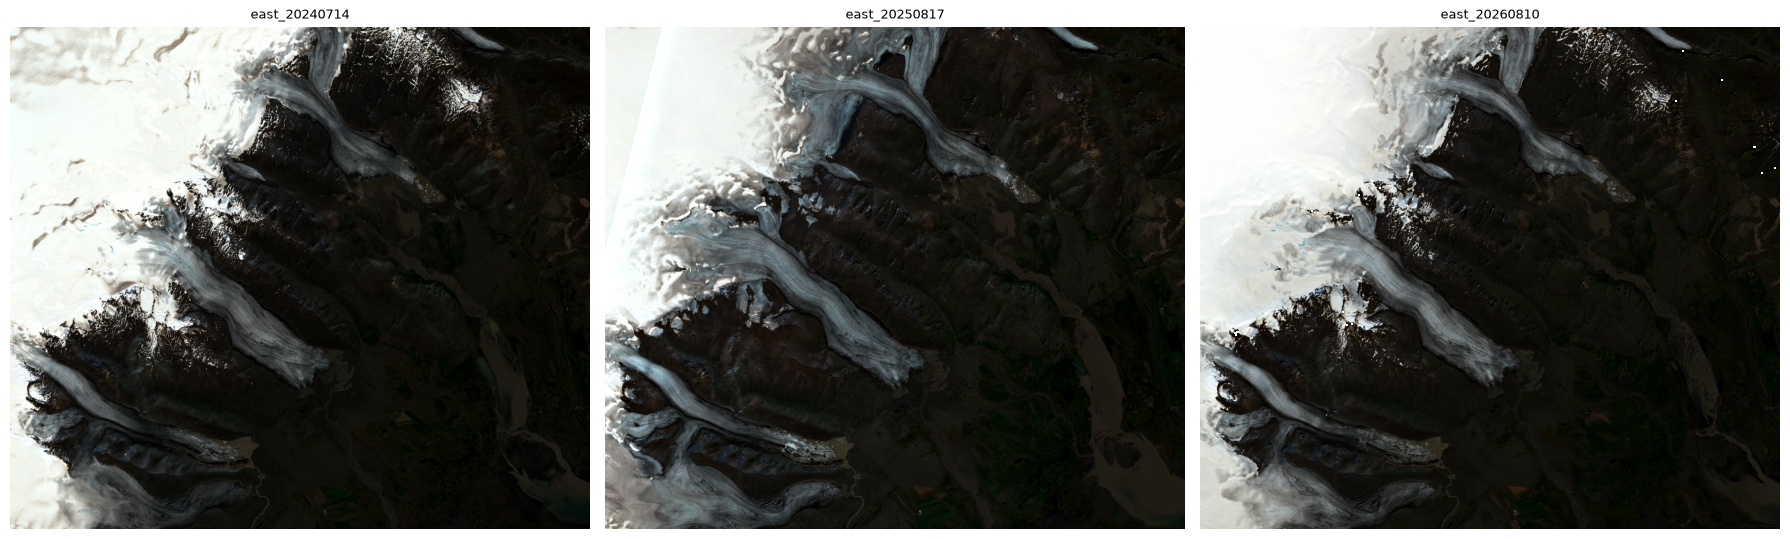

red    median 0.1068
green  median 0.1022
blue   median 0.0868
nir    median 0.1990


In [14]:
import rioxarray
show = written[-3:] if len(written) >= 3 else written
fig, ax = plt.subplots(1, len(show), figsize=(6*len(show), 6))
for a, f in zip(np.atleast_1d(ax), show):
    t = rioxarray.open_rasterio(f).values          # (band, y, x) = r,g,b,nir
    rgbim = np.dstack([t[0], t[1], t[2]])
    lo, hi = np.nanpercentile(rgbim[np.isfinite(rgbim)], [2, 98])
    a.imshow(np.clip((rgbim - lo) / (hi - lo + 1e-9), 0, 1))
    a.set_title(Path(f).stem, fontsize=9); a.axis("off")
plt.tight_layout(); plt.show()

# medians should be consistent with the other area (same to_reflectance)
t = rioxarray.open_rasterio(written[-2]).values
for i, b in enumerate(["red", "green", "blue", "nir"]):
    v = t[i][(t[i] > 0) & np.isfinite(t[i])]
    print(f"{b:6s} median {np.median(v):.4f}")